In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs                 # For plotting maps
import cartopy.feature as cfeature         # For plotting maps
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
import warnings

In [2]:
#read in timeseries of: NADP NTN and ensure correct/consistent formatting

# subset for NTN comparisons: SO4, NH4, NO3 (downloaded NADP NTN 2002-2023 for all sites at weekly scale on 3/25/2024 excluding invalids)
pathData = '/glade/u/home/demurray/External File Uploads/NADP NTN wet dep data'
os.chdir(pathData)
nadp_df_all = pd.read_csv('NTN-ALL-Weekly 2000_2022.csv', parse_dates = ['dateOn', 'dateOff'])
nadp_df_all = nadp_df_all[['siteId', 'dateOn', 'dateOff','NH4', 'NO3', 'SO4', 'subppt', 'flagNH4','flagNO3','flagSO4','invalcode', 'valcode']]

#Clean the observed data
nadp_df = nadp_df_all.loc[nadp_df_all.subppt != 0,]#remove rows where there is no precipitation recorded
nadp_df = nadp_df.loc[nadp_df['invalcode'] == '            '] #keep only the data with no invalid codes
nadp_df = nadp_df.loc[nadp_df['valcode'] !='t ',] #remove data with valid code but are trace 
nadp_df = nadp_df.loc[nadp_df['valcode'] !='d ',] #remove data with valid code but are dry
nadp_df  = nadp_df .loc[nadp_df.flagNH4 != '<',] #removed lab flagged NH4 datapoints 
nadp_df  = nadp_df .loc[nadp_df.flagNO3 != '<',] #removed lab flagged NO3 datapoints 
nadp_df  = nadp_df .loc[nadp_df.flagSO4 != '<',] #removed lab flagged SO4 datapoints 
nadp_df[nadp_df.select_dtypes(include='number') < 0] = np.nan #missing data that was denoted as -9.00 assigned as nan values 
nadp_df

,siteId,dateOn,dateOff,NH4,NO3,SO4,subppt,flagNH4,flagNO3,flagSO4,invalcode,valcode
2,AB32,2016-09-28 16:00:00,2016-10-05 16:55:00,0.039,0.190,0.382,18.034,,,,,w
5,AB32,2016-10-18 20:00:00,2016-10-25 18:00:00,0.343,1.812,1.108,3.556,,,,,w
6,AB32,2016-10-25 18:00:00,2016-10-31 16:47:00,0.866,1.996,1.398,4.572,,,,,w
7,AB32,2016-10-31 16:47:00,2016-11-07 17:00:00,0.125,0.283,0.584,1.524,,,,,w
8,AB32,2016-11-07 17:00:00,2016-11-15 16:00:00,0.269,1.413,0.558,0.254,,,,,wi
...,...,...,...,...,...,...,...,...,...,...,...,...
295857,WY99,2022-07-20 17:23:00,2022-07-26 19:45:00,0.849,1.487,0.659,24.130,,,,,w
295860,WY99,2022-08-11 18:55:00,2022-08-15 18:35:00,0.518,0.822,0.213,30.988,,,,,w
295862,WY99,2022-08-25 20:33:00,2022-08-31 18:35:00,0.779,1.499,0.629,6.463,,,,,w
295865,WY99,2022-09-13 16:40:00,2022-09-20 16:28:00,0.314,1.116,0.454,22.098,,,,,w


In [3]:
#Assign units and start unit conversions
nadp_df = nadp_df.rename(columns = {'SO4':'SO4_mgL', 'NH4':'NH4_mgL', 'NO3':'NO3_mgL', 'subppt':'ppt_mm', }) #assign units

#Scale concentrations to mg/m2 using precip volume, assuming 1mm rain = 1L/m2
nadp_df['SO4_mgm2'] = (nadp_df['SO4_mgL'] * nadp_df['ppt_mm'])
nadp_df['NH4_mgm2'] = (nadp_df['NH4_mgL'] * nadp_df['ppt_mm'])
nadp_df['NO3_mgm2'] = (nadp_df['NO3_mgL'] * nadp_df['ppt_mm'])

#merge with site info and then select relevant columns
ntn = pd.read_csv('ntn.csv')
nadp_df = pd.merge(nadp_df, ntn, on = 'siteId')
nadp_df = nadp_df[['siteId','latitude', 'longitude', 'dateOn', 'dateOff', 'SO4_mgm2', 'NO3_mgm2', 'NH4_mgm2', 'ppt_mm']]
nadp_df['year'] = nadp_df['dateOff'].dt.year
nadp_df['lon'] = 360-(nadp_df['longitude']*-1)
nadp_df

,siteId,latitude,longitude,dateOn,dateOff,SO4_mgm2,NO3_mgm2,NH4_mgm2,ppt_mm,year,lon
0,AB32,57.1894,-111.6406,2016-09-28 16:00:00,2016-10-05 16:55:00,6.888988,3.426460,0.703326,18.034,2016,248.3594
1,AB32,57.1894,-111.6406,2016-10-18 20:00:00,2016-10-25 18:00:00,3.940048,6.443472,1.219708,3.556,2016,248.3594
2,AB32,57.1894,-111.6406,2016-10-25 18:00:00,2016-10-31 16:47:00,6.391656,9.125712,3.959352,4.572,2016,248.3594
3,AB32,57.1894,-111.6406,2016-10-31 16:47:00,2016-11-07 17:00:00,0.890016,0.431292,0.190500,1.524,2016,248.3594
4,AB32,57.1894,-111.6406,2016-11-07 17:00:00,2016-11-15 16:00:00,0.141732,0.358902,0.068326,0.254,2016,248.3594
...,...,...,...,...,...,...,...,...,...,...,...
191305,WY99,43.8730,-104.1917,2022-07-20 17:23:00,2022-07-26 19:45:00,15.901670,35.881310,20.486370,24.130,2022,255.8083
191306,WY99,43.8730,-104.1917,2022-08-11 18:55:00,2022-08-15 18:35:00,6.600444,25.472136,16.051784,30.988,2022,255.8083
191307,WY99,43.8730,-104.1917,2022-08-25 20:33:00,2022-08-31 18:35:00,4.065227,9.688037,5.034677,6.463,2022,255.8083
191308,WY99,43.8730,-104.1917,2022-09-13 16:40:00,2022-09-20 16:28:00,10.032492,24.661368,6.938772,22.098,2022,255.8083


In [4]:
#calculate annual sum
nadp_df_annsum = nadp_df.groupby(['siteId', 'latitude', 'longitude', 'lon', 'year'])[['SO4_mgm2', 'NO3_mgm2','NH4_mgm2', 'ppt_mm']].sum().reset_index()
nadp_df_annsum

#calculate total annual average
nadp_df_totannavg = nadp_df_annsum.groupby(['siteId', 'latitude', 'longitude']).mean().reset_index()
nadp_df_totannavg = nadp_df_totannavg[['siteId', 'latitude', 'longitude', 'lon', 'SO4_mgm2', 'NO3_mgm2','NH4_mgm2', 'ppt_mm']]

#Convert to g
nadp_df_totannavg['SO4_gm2'] = (nadp_df_totannavg['SO4_mgm2']) * 0.001
nadp_df_totannavg['NH4_gm2'] = (nadp_df_totannavg['NH4_mgm2']) * 0.001
nadp_df_totannavg['NO3_gm2'] = (nadp_df_totannavg['NO3_mgm2']) * 0.001
nadp_df_totannavg['ppt_m'] = (nadp_df_totannavg['ppt_mm']) * 0.001

nadp_df_totannavg

,siteId,latitude,longitude,lon,SO4_mgm2,NO3_mgm2,NH4_mgm2,ppt_mm,SO4_gm2,NH4_gm2,NO3_gm2,ppt_m
0,AB32,57.1894,-111.6406,248.3594,171.056985,151.704449,47.325589,279.036571,0.171057,0.047326,0.151704,0.279037
1,AB34,55.6214,-111.1727,248.8273,149.951343,182.512062,75.173829,384.515250,0.149951,0.075174,0.182512,0.384515
2,AB36,57.2592,-111.0386,248.9614,136.101654,116.828808,30.143756,258.594500,0.136102,0.030144,0.116829,0.258595
3,AG01,-30.9501,-62.8244,297.1756,274.943312,292.679484,346.288294,507.971429,0.274943,0.346288,0.292679,0.507971
4,AK01,65.1550,-147.4910,212.5090,33.183033,30.004711,11.044006,154.200217,0.033183,0.011044,0.030005,0.154200
...,...,...,...,...,...,...,...,...,...,...,...,...
333,WY94,43.8333,-110.7008,249.2992,113.339194,228.071097,111.160909,406.213231,0.113339,0.111161,0.228071,0.406213
334,WY95,41.3647,-106.2408,253.7592,320.578224,506.698409,140.726657,1057.570565,0.320578,0.140727,0.506698,1.057571
335,WY97,42.4944,-108.8320,251.1680,107.987087,171.617411,52.282322,307.570217,0.107987,0.052282,0.171617,0.307570
336,WY98,43.2227,-109.9917,250.0083,110.869497,182.752851,75.544456,333.407522,0.110869,0.075544,0.182753,0.333408


In [5]:
#read in DOC_BC data and subset DOC and merge with nadp_df
pathData = '/glade/u/home/demurray/External File Uploads/DOC data/'
os.chdir(pathData)
doc_df = pd.read_csv('DOC_BC_wetdep_compiled.csv', parse_dates = ['dateOn', 'dateOff'])
doc_df = doc_df.loc[doc_df.Variable == 'DOC_mgL',]
doc_df['DOC_mgm2'] = (doc_df['Value'] * doc_df['Precip_mm']) 
doc_df['year'] = doc_df['dateOff'].dt.year
doc_df['lon'] = 360-(doc_df['longitude']*-1)

#calculate annual sum
doc_df_annsum = doc_df.groupby(['siteId', 'latitude', 'longitude', 'lon', 'year'])[['DOC_mgm2']].sum().reset_index()
doc_df_annsum

#calculate total annual average
doc_df_totannavg = doc_df_annsum.groupby(['siteId', 'latitude', 'longitude']).mean().reset_index()
doc_df_totannavg = doc_df_totannavg[['siteId', 'latitude', 'longitude', 'lon', 'DOC_mgm2']]

#Convert to g
doc_df_totannavg['DOC_gm2'] = (doc_df_totannavg['DOC_mgm2']) * 0.001
doc_df_totannavg

,siteId,latitude,longitude,lon,DOC_mgm2,DOC_gm2
0,AK02,58.513900,-134.784300,225.215700,156.938980,0.156939
1,AZ03,36.058600,-112.184000,247.816000,93.326080,0.093326
2,CA96,40.539000,-121.577200,238.422800,151.571960,0.151572
3,CO90,40.050000,-105.583000,254.417000,587.169408,0.587169
4,GA09,30.740400,-82.128300,277.871700,222.935800,0.222936
5,IA23,40.963100,-93.392500,266.607500,179.632610,0.179633
6,LA30,30.781900,-90.202100,269.797900,293.530020,0.293530
7,ME09,45.489100,-69.664700,290.335300,186.246770,0.186247
8,MN16,47.531100,-93.468600,266.531400,1634.086333,1.634086
9,MN32,48.413200,-92.830500,267.169500,134.429735,0.134430


In [6]:
warnings.filterwarnings("ignore") # Suppress specific warning types

years_per_site = pd.DataFrame()
for i in doc_df.siteId.unique():
    dat = doc_df.loc[doc_df.siteId == i,]
    dat['year_min'] = dat.year.min()
    dat['year_max'] = dat.year.max()
    dat['years_tot'] = dat['year_max'] - dat['year_min']
    dat_years = dat[['siteId', 'years_tot']].drop_duplicates()
    years_per_site = pd.concat([years_per_site, dat_years])
#years_per_site

doc_df_totannavg = pd.merge(doc_df_totannavg, years_per_site, on = 'siteId')
doc_df_totannavg

,siteId,latitude,longitude,lon,DOC_mgm2,DOC_gm2,years_tot
0,AK02,58.513900,-134.784300,225.215700,156.938980,0.156939,1.0
1,AZ03,36.058600,-112.184000,247.816000,93.326080,0.093326,1.0
2,CA96,40.539000,-121.577200,238.422800,151.571960,0.151572,1.0
3,CO90,40.050000,-105.583000,254.417000,587.169408,0.587169,12.0
4,GA09,30.740400,-82.128300,277.871700,222.935800,0.222936,1.0
5,IA23,40.963100,-93.392500,266.607500,179.632610,0.179633,1.0
6,LA30,30.781900,-90.202100,269.797900,293.530020,0.293530,1.0
7,ME09,45.489100,-69.664700,290.335300,186.246770,0.186247,1.0
8,MN16,47.531100,-93.468600,266.531400,1634.086333,1.634086,5.0
9,MN32,48.413200,-92.830500,267.169500,134.429735,0.134430,1.0


In [7]:
#Read in SO4, NO3, NH4, NH3 wet dep timeseries files
daily_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
daily_so4_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_HNO3.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH4.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH3.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a3SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c3SFWET.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [daily_result_dir / file_name for file_name in daily_so4_files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily = xr.open_mfdataset(file_paths, combine='nested')

In [8]:
# Calculate SO4_wet_sum
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1 * 0.843478

# Calculate NO3_wet
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006 #correct for HNO3 molar mass

# Calculate NH4_wet
nc_daily['WD_NH4_corr'] = nc_daily['WD_NH4'] * -1
nc_daily['WD_NH4_corr'] = nc_daily['WD_NH4_corr'].where(nc_daily['WD_NH4_corr'] != -0.0, 0.0)

# Calculate NH3_wet
nc_daily['WD_NH3_corr'] = nc_daily['WD_NH3'] * -1
nc_daily['WD_NH3_corr'] = nc_daily['WD_NH3_corr'].where(nc_daily['WD_NH3_corr'] != -0.0, 0.0)

#Calculate NH4 and NH3 sum
nc_daily['WD_NH4_NH3'] = nc_daily['WD_NH4_corr'] + nc_daily['WD_NH3_corr'] 

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_corr', 'NO3_wet', 'WD_NH3_corr', 'WD_NH4_NH3'] else x)
nc_daily_sub = nc_daily[['SO4_wet_sum', 'WD_NH4_corr', 'NO3_wet', 'WD_NH3_corr', 'WD_NH4_NH3']]

In [9]:
#Calculate the total annual average for each solute
# assign year
nc_daily_sub['year'] = nc_daily_sub['time'].dt.year

#group by year and calculate sum (total amount of solute per year), then take average of sum (total annual average)
nc_daily_sub_yearsum = nc_daily_sub.groupby('year').sum()
nc_daily_sub_totannavg = nc_daily_sub_yearsum.mean(dim = 'year')

#convert to grams/m2
nc_daily_sub_totannavg['SO4_wet_sum_gm2'] = nc_daily_sub_totannavg ['SO4_wet_sum'] * 0.001
nc_daily_sub_totannavg['NO3_wet_gm2'] = nc_daily_sub_totannavg ['NO3_wet'] * 0.001
nc_daily_sub_totannavg['WD_NH4_corr_gm2'] = nc_daily_sub_totannavg ['WD_NH4_corr'] * 0.001
nc_daily_sub_totannavg['WD_NH3_corr_gm2'] = nc_daily_sub_totannavg ['WD_NH3_corr'] * 0.001
nc_daily_sub_totannavg['WD_NH4_NH3_corr_gm2'] = nc_daily_sub_totannavg ['WD_NH4_NH3'] * 0.001

nc_daily_sub_totannavg


<xarray.Dataset>
Dimensions:              (lat: 192, lon: 288)
Coordinates:
  * lat                  (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon                  (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    SO4_wet_sum          (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH4_corr          (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    NO3_wet              (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH3_corr          (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH4_NH3           (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SO4_wet_sum_gm2      (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    NO3_wet_gm2          (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH4_corr_gm2      (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH3_corr_gm2      (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    WD_NH4_NH3_corr_gm2  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>

In [10]:
#Read in the precip files
precip_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2/')
precip_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECC.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECL.nc']

# Concatenate directory path with each file name separately
file_paths = [precip_result_dir / file_name for file_name in precip_files_to_open]

# Open multiple netCDF files as a single dataset
nc_precip = xr.open_mfdataset(file_paths, combine='nested') # units are in m/s
nc_precip['PRECC_mm'] = nc_precip['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_precip['PRECL_mm'] = nc_precip['PRECL']* (86400*1000)
nc_precip['PREC_tot_mm'] = nc_precip['PRECC_mm']  + nc_precip['PRECL_mm']

In [11]:
#corrent timestamp (-1), and assign year
nc_precip['year'] = nc_precip['time'].dt.year

#group by year and calculate sum (total amount of solute per year), then take average of sum (total annual average)
nc_precip_yearsum = nc_precip.groupby('year').sum()
nc_precip_totannavg = nc_precip_yearsum.mean(dim = 'year')

#convert to m
nc_precip_totannavg['PREC_tot_m'] = nc_precip_totannavg ['PREC_tot_mm'] * 0.001
nc_precip_totannavg

<xarray.Dataset>
Dimensions:      (lat: 192, lon: 288)
Coordinates:
  * lat          (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon          (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    PRECC        (lat, lon) float32 dask.array<chunksize=(192, 288), meta=np.ndarray>
    PRECL        (lat, lon) float32 dask.array<chunksize=(192, 288), meta=np.ndarray>
    PRECC_mm     (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    PRECL_mm     (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    PREC_tot_mm  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    PREC_tot_m   (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>

In [12]:
#Read in BC wet dep timeseries files
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
bc_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.a2x_BCPHIWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c4SFWET.nc']

file_paths = [result_dir / file_name for file_name in bc_files_to_open]
nc_daily_bc = xr.open_mfdataset(file_paths, combine='nested')

#read in POM files
daily_pom_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.pom_*SFWET.nc'
nc_daily_pom = xr.open_mfdataset(str(result_dir/daily_pom_to_open),combine='nested')

#read in SOA
soa_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_SOAvars/')
daily_soa_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.*SFWET.nc'
nc_daily_soa = xr.open_mfdataset(str(soa_result_dir/daily_soa_to_open),combine='nested')

#merge SOA and POM files together
nc_daily_oc = xr.merge([nc_daily_soa, nc_daily_pom, nc_daily_bc])

# Calculate DOC = SOA + POM + BC
nc_daily_oc['BC_wet_sum'] = (nc_daily_oc['bc_a1SFWET'] + nc_daily_oc['bc_a4SFWET'] + nc_daily_oc['bc_c1SFWET'] 
                                + nc_daily_oc['bc_c4SFWET']) * -1

nc_daily_oc['SOA_POM_wet_sum'] = (nc_daily_oc['soa1_a1SFWET'] + nc_daily_oc['soa1_a2SFWET'] + nc_daily_oc['soa1_c1SFWET'] 
                             + nc_daily_oc['soa1_c2SFWET'] + nc_daily_oc['soa2_a1SFWET'] + nc_daily_oc['soa2_a2SFWET'] 
                             + nc_daily_oc['soa2_c1SFWET'] +  nc_daily_oc['soa2_c2SFWET'] + nc_daily_oc['soa3_a1SFWET'] 
                             + nc_daily_oc['soa3_a2SFWET'] + nc_daily_oc['soa3_c1SFWET'] + nc_daily_oc['soa3_c2SFWET'] 
                             + nc_daily_oc['soa4_a1SFWET'] + nc_daily_oc['soa4_a2SFWET'] + nc_daily_oc['soa4_c1SFWET'] 
                             + nc_daily_oc['soa4_c2SFWET'] + nc_daily_oc['soa5_a1SFWET'] + nc_daily_oc['soa5_a2SFWET'] 
                             + nc_daily_oc['soa5_c1SFWET'] + nc_daily_oc['soa5_c2SFWET'] + nc_daily_oc['pom_a1SFWET']
                             + nc_daily_oc['pom_a4SFWET'] + nc_daily_oc['pom_c1SFWET'] + nc_daily_oc['pom_c4SFWET']) * -1

nc_daily_oc['SOA_POM_BC_wet_sum'] = nc_daily_oc['BC_wet_sum'] + nc_daily_oc['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily_oc = nc_daily_oc.apply(lambda x: x * conversions if x.name in ['BC_wet_sum', 'SOA_POM_wet_sum', 'SOA_POM_BC_wet_sum'] else x)
nc_daily_oc = nc_daily_oc[[ 'BC_wet_sum', 'SOA_POM_wet_sum', 'SOA_POM_BC_wet_sum']]
nc_daily_oc

<xarray.Dataset>
Dimensions:             (time: 7671, lat: 192, lon: 288)
Coordinates:
  * lat                 (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon                 (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time                (time) datetime64[ns] 2002-01-01 ... 2023-01-01
Data variables:
    BC_wet_sum          (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    SOA_POM_wet_sum     (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>
    SOA_POM_BC_wet_sum  (time, lat, lon) float64 dask.array<chunksize=(7671, 192, 288), meta=np.ndarray>

In [13]:
#correct timestamp (-1), and assign year
nc_daily_oc['year'] = nc_daily_oc['time'].dt.year

#group by year and calculate sum (total amount of solute per year), then take average of sum (total annual average)
nc_daily_oc_yearsum = nc_daily_oc.groupby('year').sum()
nc_daily_oc_totannavg = nc_daily_oc_yearsum.mean(dim = 'year')

#convert to m
nc_daily_oc_totannavg['BC_wet_sum_gm2'] = nc_daily_oc_totannavg ['BC_wet_sum'] * 0.001
nc_daily_oc_totannavg['SOA_POM_wet_sum_gm2'] = nc_daily_oc_totannavg ['SOA_POM_wet_sum'] * 0.001
nc_daily_oc_totannavg['SOA_POM_BC_wet_sum_gm2'] = nc_daily_oc_totannavg ['SOA_POM_BC_wet_sum'] * 0.001
nc_daily_oc_totannavg

<xarray.Dataset>
Dimensions:                 (lat: 192, lon: 288)
Coordinates:
  * lat                     (lat) float64 -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                     (lon) float64 0.0 1.25 2.5 ... 356.2 357.5 358.8
Data variables:
    BC_wet_sum              (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SOA_POM_wet_sum         (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SOA_POM_BC_wet_sum      (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    BC_wet_sum_gm2          (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SOA_POM_wet_sum_gm2     (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>
    SOA_POM_BC_wet_sum_gm2  (lat, lon) float64 dask.array<chunksize=(192, 288), meta=np.ndarray>

In [14]:
#Note for remaking map in future:
#max color ramp values:
#precip: 3
#DOC: 2
#NH4: 0.7
#NO3: 2
#SO4: 2.5

In [15]:
nadp_df_totannavg.columns

Index(['siteId', 'latitude', 'longitude', 'lon', 'SO4_mgm2', 'NO3_mgm2',
       'NH4_mgm2', 'ppt_mm', 'SO4_gm2', 'NH4_gm2', 'NO3_gm2', 'ppt_m'],
      dtype='object')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


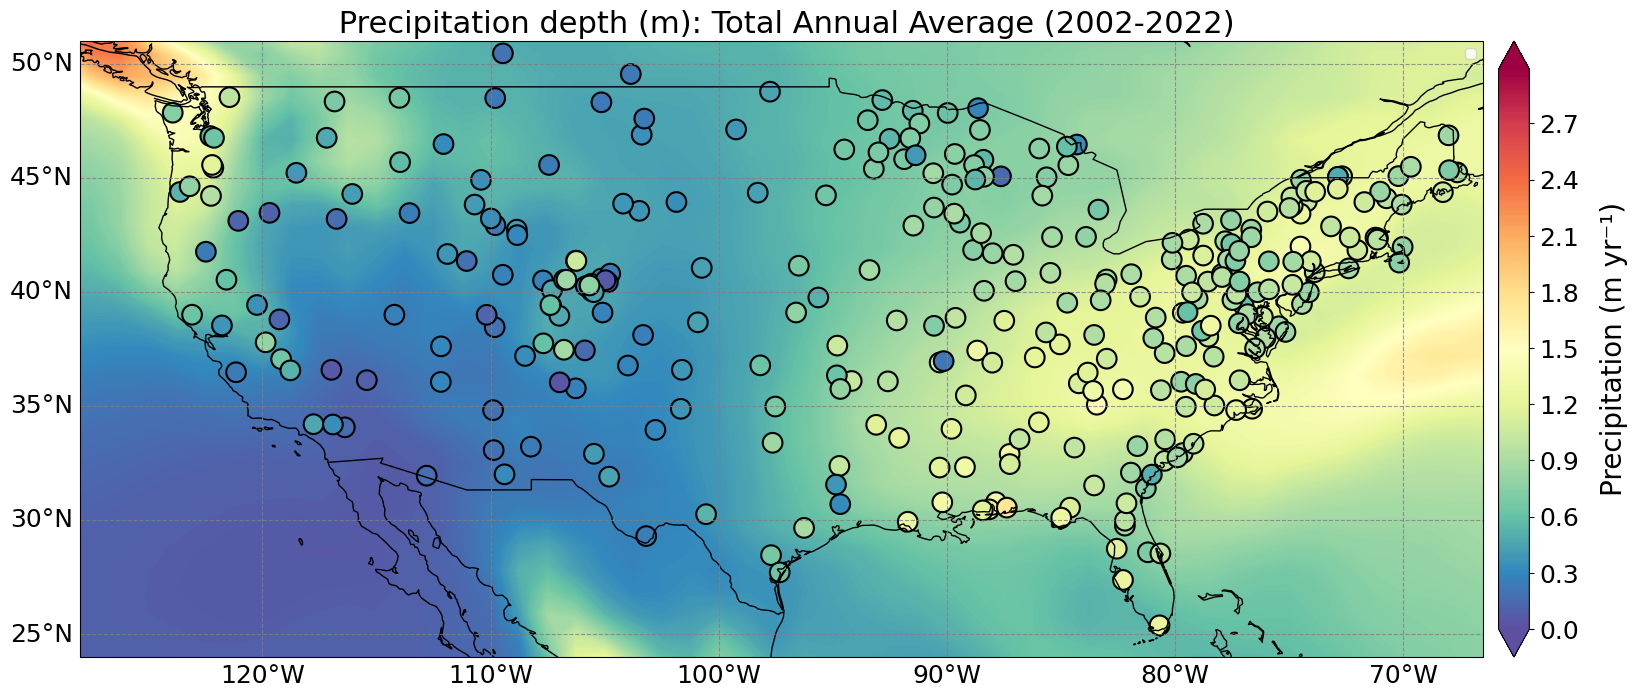

In [17]:
#make a map
warnings.filterwarnings("ignore") # Suppress specific warning types

#setup:
var_sel = nc_precip_totannavg[['PREC_tot_m']].to_dataarray()
#var_sel = nc_daily_sub_totannavg[['NO3_wet_gm2']].to_dataarray()
#var_sel = nc_daily_sub_totannavg[['WD_NH4_NH3_corr_gm2']].to_dataarray()
#var_sel = nc_daily_sub_totannavg[['SO4_wet_sum_gm2']].to_dataarray()
#var_sel = nc_daily_oc_totannavg[['SOA_POM_BC_wet_sum_gm2']].to_dataarray()
var_srf = var_sel.isel(variable=0) 

#extract grid variables
lat = var_sel.coords['lat']
lon = var_sel.coords['lon']

plt.figure(figsize=(20,8))

#Define projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Zoom to a region
#longitude limits in degrees, latitude limits in degrees
ax.set_xlim(-128,-66.5)
ax.set_ylim(24,51)

#define contour levels
clev = np.arange(0, 3, 0.01)

#plot the data
cmap = plt.cm.get_cmap('Spectral_r')
contour = plt.contourf(lon,lat,var_srf,clev, cmap=cmap,extend='both')

# add coastlines
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

#add lat lon grids
gl = ax.gridlines(draw_labels=True, color='grey', alpha=0.8, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}

# Titles
plt.title(" Precipitation depth (m): Total Annual Average (2002-2022)",fontsize=22)
#plt.title(" Wet Deposition $NH_{4}$ + $NH_{3}$: Total Annual Average (2002-2022)",fontsize=26)
#plt.title(" Wet Deposition DOC: Total Annual Average (2002-2022)",fontsize=22)
#plt.title(" Wet Deposition $SO4_{4}$: Total Annual Average (2002-2022)",fontsize=26)

# y-axis
ax.text(-0.04, 0.5, '', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax.transAxes, fontsize=20)

# x-axis
ax.text(0.5, -0.08, '', va='bottom', ha='center',
        rotation='horizontal', rotation_mode='anchor',
        transform=ax.transAxes, fontsize=20)

# Add color bar
cbar = plt.colorbar(contour, pad=0.01, fraction=0.03)  # Adjust pad and fraction values as needed
cbar.set_label('Precipitation (m yr⁻¹)', labelpad=15, fontsize=20)  # Adjust labelpad value as needed
#cbar.set_label('$SO_{4}$ (g m⁻² yr⁻¹)', labelpad=15, fontsize=24)  # Adjust labelpad value as needed
#cbar.set_label('DOC (g m⁻² yr⁻¹)', labelpad=15, fontsize=20)  # Adjust labelpad value as needed
cbar.ax.tick_params(labelsize=18)  # Adjust color bar tick size

#Overlay points
#nadp_df_totannavg_var = doc_df_totannavg[['siteId', 'doc_gm2', 'latitude', 'lon']]#, 'years_tot']]
nadp_df_totannavg_var = nadp_df_totannavg[['siteId', 'ppt_m', 'latitude', 'lon']]#, 'years_tot']]
nadp_df_totannavg_var.dropna(inplace = True)

#first we need to define our observational data into an array
latpt = np.array(nadp_df_totannavg_var['latitude'])
lonpt = np.array(nadp_df_totannavg_var['lon'])
#year = np.array(doc_df_totannavg_var['years_tot'])

obs_var = np.array(nadp_df_totannavg_var['ppt_m'])

#this is needed for convert the observation to the position on the basemap color gradient defined above
norm = plt.Normalize(vmin=clev.min(), vmax=clev.max())
colors = cmap(norm(obs_var))

ax.scatter(lonpt, latpt, c=colors, marker='o', s = 200, edgecolors="black", linewidths=1.5, transform=ccrs.PlateCarree())
plt.legend()
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Total Annual Average precip Map.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()